<a href="https://colab.research.google.com/github/440g/painkiller/blob/Model%26Evaluation/src/model_and_Evaluation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Model training and validation
* Selection of multiple machine learning algorithms.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
import pandas as pd

X_train = pd.read_csv('../datasets/X_train_re2.csv')

# X_train = X_train.drop(columns=['Unnamed: 0'])
y_train = pd.read_csv('../datasets/y_train_re2.csv')
X_val = pd.read_csv('../datasets/X_train_val_re2.csv')
# X_val = X_val.drop(columns=['Unnamed: 0'])
y_val = pd.read_csv('../datasets/y_train_val_re2.csv')

In [4]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier, RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

from sklearn.model_selection import KFold, GridSearchCV

In [5]:
kf = KFold(n_splits=3, shuffle=True, random_state=42)
scoring = "roc_auc"

models = {}

### 1. Decision Tree

In [6]:
model = DecisionTreeClassifier(random_state=42)


param_grid = {
    "max_depth": [5, 10, 20],
    "min_samples_split": [2, 10, 20],
    "ccp_alpha": [0.0, 0.01],
}

grid_search = GridSearchCV(model, param_grid, cv=kf, scoring=scoring, refit=True, n_jobs=-1)
grid_search.fit(X_train, y_train['y'])

print("Best parameters: ", grid_search.best_params_)
print("Best CV score: {:.6f}".format(grid_search.best_score_))

models["Decision Tree"] = grid_search.best_estimator_

Best parameters:  {'ccp_alpha': 0.0, 'max_depth': 5, 'min_samples_split': 2}
Best CV score: 0.652344


### 2. Bagging

In [7]:
model = BaggingClassifier(estimator=DecisionTreeClassifier(), n_jobs=-1, random_state=42)


param_grid = {
    "n_estimators": [10, 25, 50]
}

grid_search = GridSearchCV(model, param_grid, cv=kf, scoring=scoring, refit=True, n_jobs=-1)
grid_search.fit(X_train, y_train['y'])

print("Best parameters: ", grid_search.best_params_)
print("Best CV score: {:.6f}".format(grid_search.best_score_))

models["Bagging"] = grid_search.best_estimator_

Best parameters:  {'n_estimators': 50}
Best CV score: 0.690884


### 3. Random Forest



In [9]:
model = RandomForestClassifier(n_jobs=-1, random_state=42)


param_grid = {
    "n_estimators": [50, 100, 300],
    "max_depth": [5, 10, 20],
    "max_features": ["sqrt", "log2"],
}

grid_search = GridSearchCV(model, param_grid, cv=kf, scoring=scoring, refit=True, n_jobs=-1)
grid_search.fit(X_train, y_train['y'])

print("Best parameters: ", grid_search.best_params_)
print("Best CV score: {:.6f}".format(grid_search.best_score_))

models["Random Forest"] = grid_search.best_estimator_

Best parameters:  {'max_depth': 20, 'max_features': 'sqrt', 'n_estimators': 300}
Best CV score: 0.708378


### 4. AdaBoost

In [10]:
model = AdaBoostClassifier(random_state=42)


param_grid = {
    # Compare low vs high max_depth for overfitting vs performance
    "estimator": [DecisionTreeClassifier(max_depth=3), DecisionTreeClassifier(max_depth=6)],
    "learning_rate": [0.1, 1.0],
}

grid_search = GridSearchCV(model, param_grid, cv=kf, scoring=scoring, refit=True, n_jobs=-1)
grid_search.fit(X_train, y_train['y'])

print("Best parameters: ", grid_search.best_params_)
print("Best CV score: {:.6f}".format(grid_search.best_score_))

models["AdaBoost"] = grid_search.best_estimator_

Best parameters:  {'estimator': DecisionTreeClassifier(max_depth=6), 'learning_rate': 0.1}
Best CV score: 0.709451


### 5. Gradient Boosting

In [11]:
model = GradientBoostingClassifier(random_state=42)

param_grid = {
    "max_depth": [3, 6],
    "learning_rate": [0.05, 0.1, 0.5],
    "n_estimators": [50, 100, 500],
    "max_features" : ['log2', 'sqrt']
}

grid_search = GridSearchCV(model, param_grid, cv=kf, scoring=scoring, refit=True, n_jobs=-1)
grid_search.fit(X_train, y_train['y'])

print("Best parameters: ", grid_search.best_params_)
print("Best CV score: {:.6f}".format(grid_search.best_score_))

models["Gradient Boosting"] = grid_search.best_estimator_

Best parameters:  {'learning_rate': 0.05, 'max_depth': 3, 'max_features': 'log2', 'n_estimators': 500}
Best CV score: 0.719227


### 6. XG Boost

In [12]:
model = XGBClassifier(n_jobs=-1, random_state=42)

param_grid = {
    "n_estimators": [50, 100],
    "learning_rate" : [0.1, 0.3],

    # Test if L1/L2 regularization improves performance with many features
    "reg_alpha": [0, 0.1],
    "reg_lambda": [0, 0.1],
}

grid_search = GridSearchCV(model, param_grid, cv=kf, scoring=scoring, refit=True)
grid_search.fit(X_train, y_train['y'])

print("Best parameters: ", grid_search.best_params_)
print("Best CV score: {:.6f}".format(grid_search.best_score_))

models["XGBoost"] = grid_search.best_estimator_

Best parameters:  {'learning_rate': 0.1, 'n_estimators': 50, 'reg_alpha': 0.1, 'reg_lambda': 0}
Best CV score: 0.711570


### 7. Light GBM

In [13]:
model = LGBMClassifier(force_col_wise=True,
                      verbosity=0,
                      n_jobs=-1,
                      random_state=42)

# Remove special characters for LightGBM compatibility
X_train_lgbm = X_train.copy()
X_val_lgbm = X_val.copy()
X_train_lgbm.columns = X_train_lgbm.columns.str.replace(r"[^\w]", "_", regex = True)
X_val_lgbm.columns = X_val_lgbm.columns.str.replace(r"[^\w]", "_", regex = True)

param_grid = {
    "n_estimators": [50, 100, 500],
    "learning_rate" : [0.05, 0.1],

    # Test if L1/L2 regularization improves performance with many features
    "reg_alpha": [0, 0.1],
    "reg_lambda": [0, 0.1],

    # Compare speed and performance with feature bundling
    "enable_bundle": [True, False]
}

grid_search = GridSearchCV(model, param_grid, cv=kf, scoring=scoring, refit=True)
grid_search.fit(X_train_lgbm, y_train['y'])

print("Best parameters: ", grid_search.best_params_)
print("Best CV score: {:.6f}".format(grid_search.best_score_))

models["LightGBM"] = grid_search.best_estimator_

Best parameters:  {'enable_bundle': True, 'learning_rate': 0.05, 'n_estimators': 100, 'reg_alpha': 0.1, 'reg_lambda': 0}
Best CV score: 0.715750


# Evaluation

In [14]:
from sklearn.metrics import f1_score, accuracy_score, roc_auc_score

y_probas = {}

for _name, _model in models.items():
    y_pred = _model.predict(X_val)
    y_proba = _model.predict_proba(X_val)[:, 1]

    f1 = f1_score (y_val["y"], y_pred)
    accuracy = accuracy_score(y_val["y"], y_pred)
    AUC = roc_auc_score (y_val["y"], y_proba)
    Main_Evaluation = (f1 + accuracy + AUC)/3

    y_probas[_name] = y_proba

    print("{:>17}: f1 = {:.4f} | accuracy = {:.4f} | AUC = {:.4f} | Main Evaluation = {:.4f}".format(
        _name, f1, accuracy, AUC, Main_Evaluation))



    Decision Tree: f1 = 0.6275 | accuracy = 0.6158 | AUC = 0.6543 | Main Evaluation = 0.6325
          Bagging: f1 = 0.6139 | accuracy = 0.6304 | AUC = 0.6862 | Main Evaluation = 0.6435
    Random Forest: f1 = 0.6475 | accuracy = 0.6518 | AUC = 0.7059 | Main Evaluation = 0.6684
         AdaBoost: f1 = 0.6438 | accuracy = 0.6544 | AUC = 0.7121 | Main Evaluation = 0.6701
Gradient Boosting: f1 = 0.6558 | accuracy = 0.6616 | AUC = 0.7209 | Main Evaluation = 0.6794
          XGBoost: f1 = 0.6488 | accuracy = 0.6557 | AUC = 0.7134 | Main Evaluation = 0.6727
         LightGBM: f1 = 0.6508 | accuracy = 0.6548 | AUC = 0.7147 | Main Evaluation = 0.6735


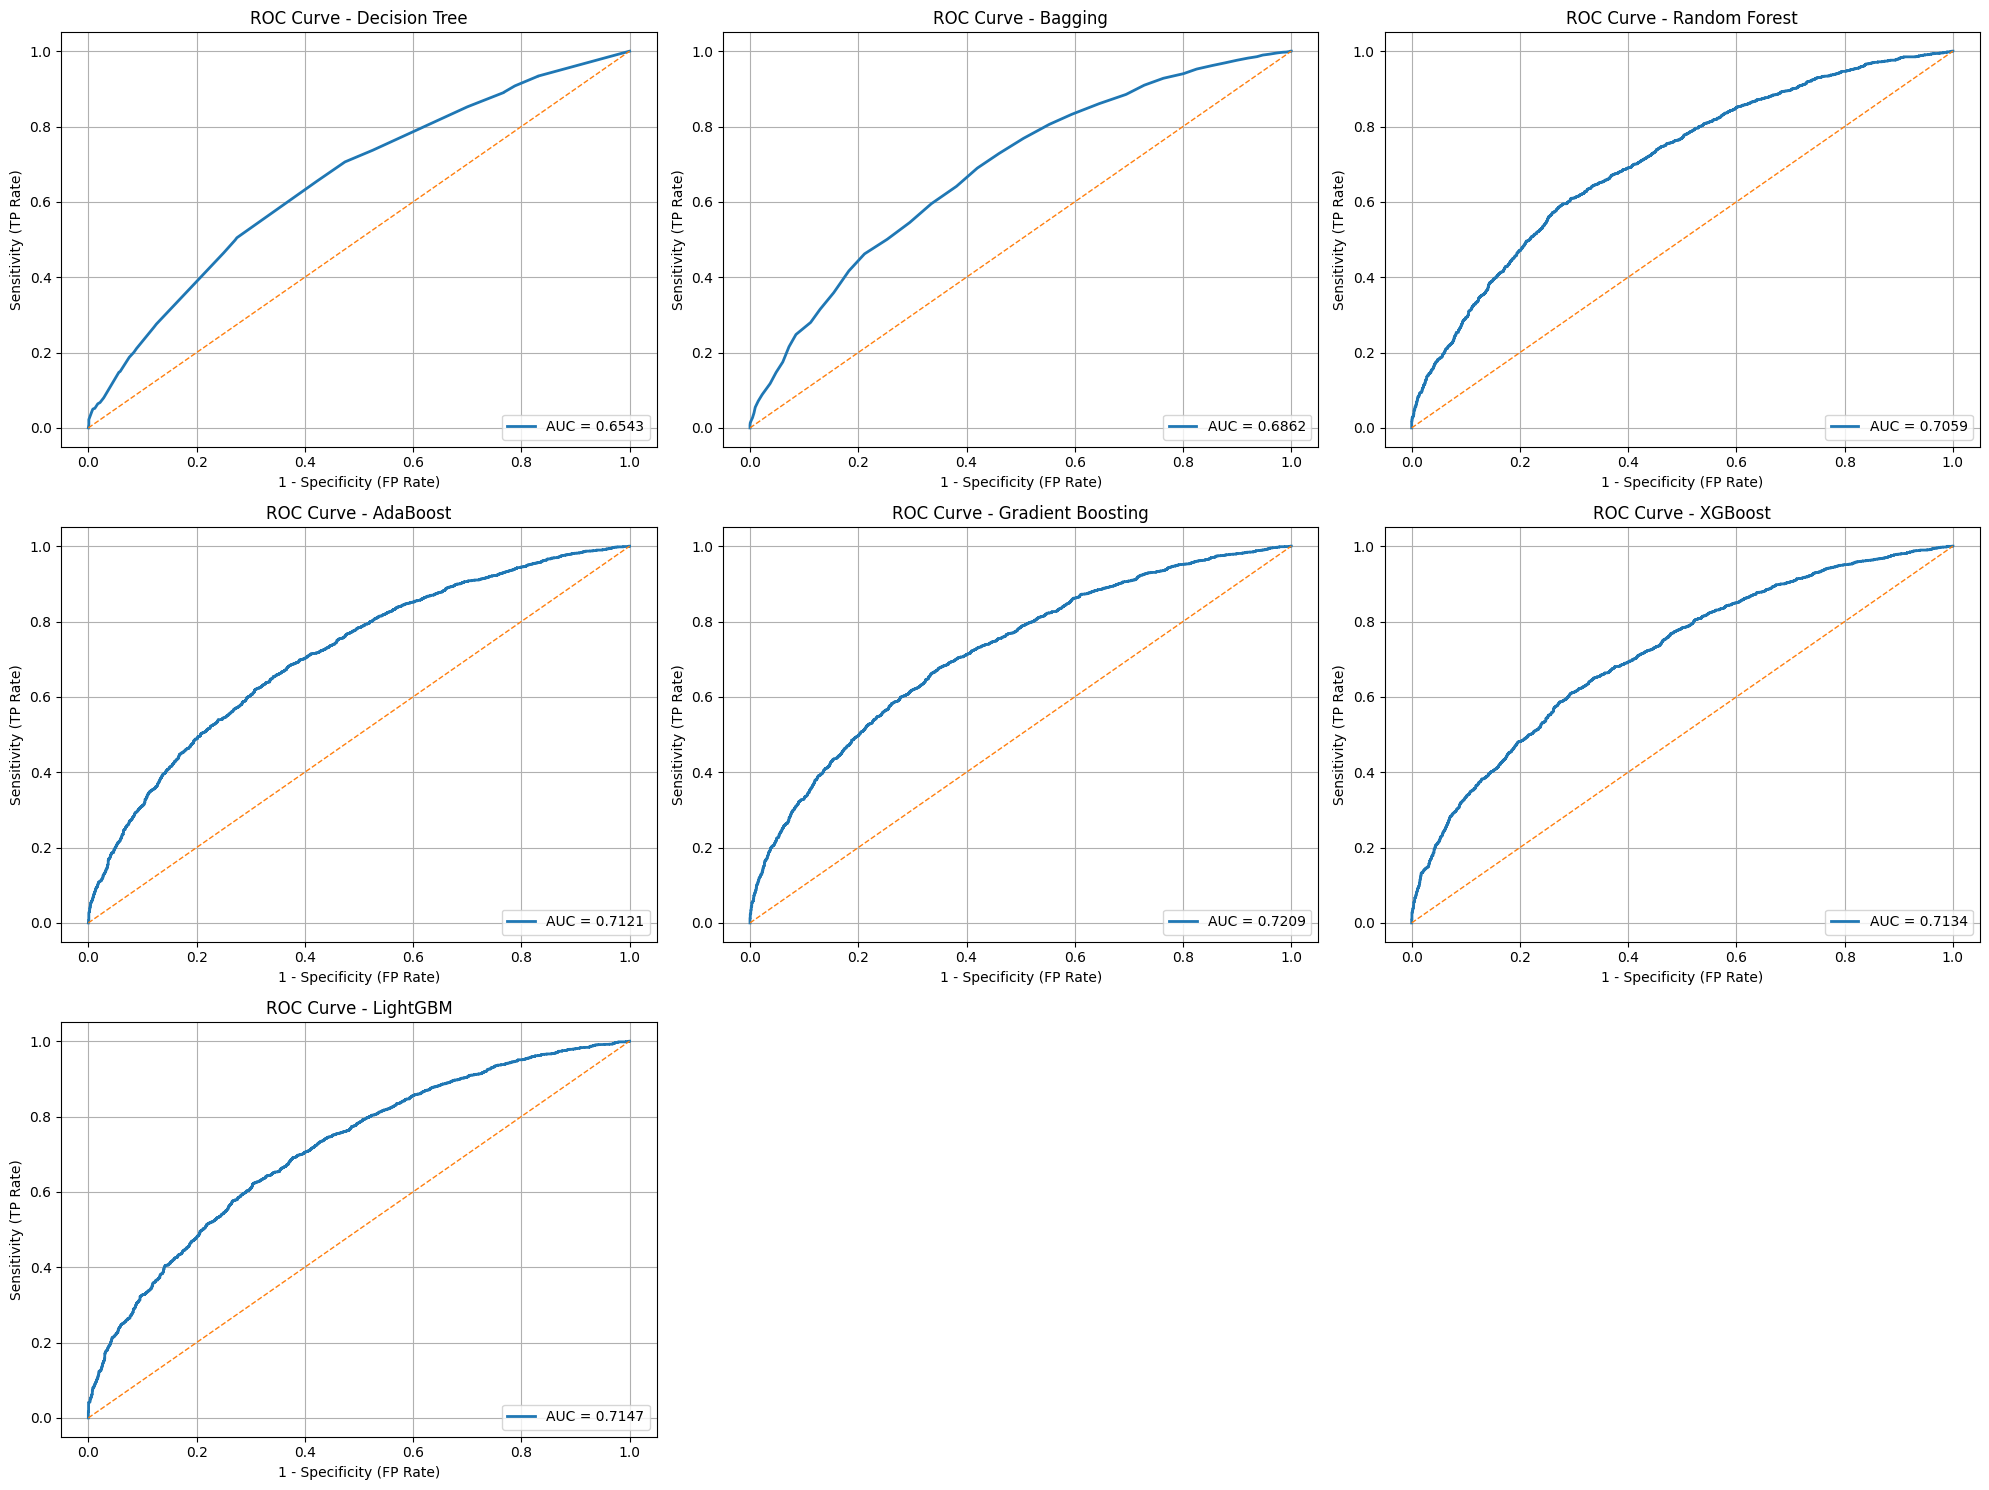

In [15]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

plt.figure(figsize=(20, 15))
for i, (name, y_proba) in enumerate(y_probas.items()):
    fpr, tpr, _ = roc_curve(y_val["y"], y_proba)
    auc = roc_auc_score(y_val["y"], y_proba)

    plt.subplot(3, 3, i + 1)
    plt.plot(fpr, tpr, lw=2, label=f"AUC = {auc:.4f}")
    plt.plot([0, 1], [0, 1], lw=1, linestyle="--")
    plt.xlabel("1 - Specificity (FP Rate)")
    plt.ylabel("Sensitivity (TP Rate)")
    plt.title(f"ROC Curve - {name}")
    plt.legend(loc="lower right")
    plt.grid(True)

plt.tight_layout()
plt.show()

In [16]:
from sklearn.metrics import confusion_matrix
import pandas as pd

for name, model in models.items():
    y_pred = model.predict(X_val)
    conf_matrix = confusion_matrix(y_val["y"], y_pred)

    conf_matrix_df = pd.DataFrame(
        conf_matrix,
        columns=["Predicted 0", "Predicted 1"],
        index=["Actual 0", "Actual 1"]
    )

    print(f"\n\nConfusion Matrix for {name}:\n")
    print(conf_matrix_df)




Confusion Matrix for Decision Tree:

          Predicted 0  Predicted 1
Actual 0         1258          921
Actual 1          733         1393


Confusion Matrix for Bagging:

          Predicted 0  Predicted 1
Actual 0         1449          730
Actual 1          861         1265


Confusion Matrix for Random Forest:

          Predicted 0  Predicted 1
Actual 0         1429          750
Actual 1          749         1377


Confusion Matrix for AdaBoost:

          Predicted 0  Predicted 1
Actual 0         1472          707
Actual 1          781         1345


Confusion Matrix for Gradient Boosting:

          Predicted 0  Predicted 1
Actual 0         1460          719
Actual 1          738         1388


Confusion Matrix for XGBoost:

          Predicted 0  Predicted 1
Actual 0         1454          725
Actual 1          757         1369


Confusion Matrix for LightGBM:

          Predicted 0  Predicted 1
Actual 0         1434          745
Actual 1          741         1385


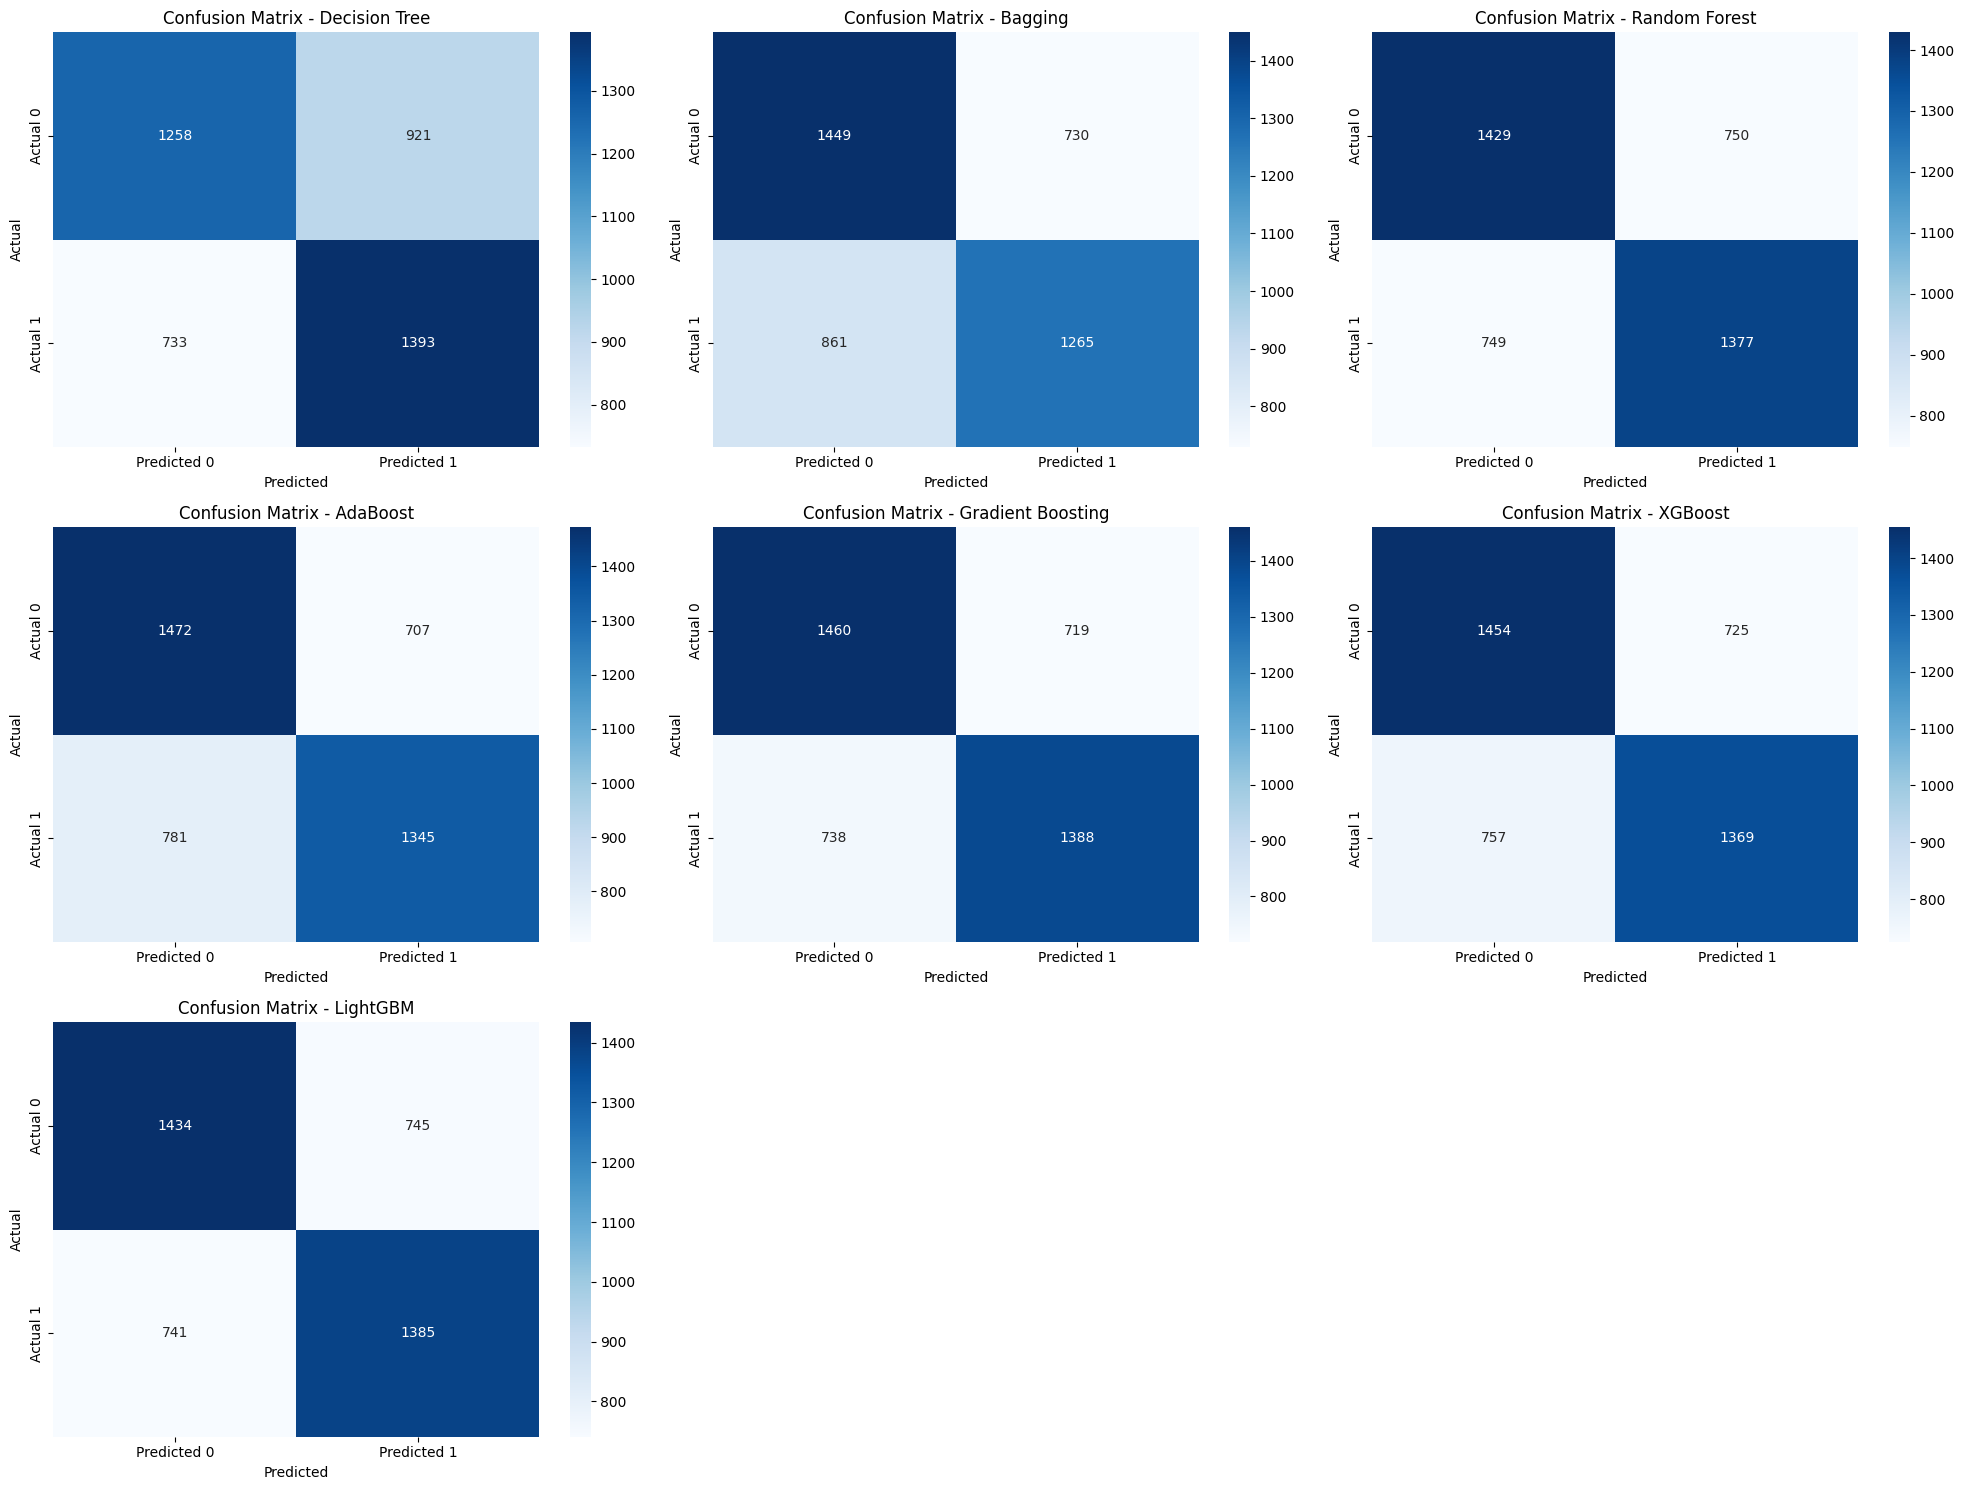

In [17]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import pandas as pd

plt.figure(figsize=(20, 15))
for i, (name, model) in enumerate(models.items()):
    y_pred = model.predict(X_val)
    cm = confusion_matrix(y_val["y"], y_pred)
    cm_df = pd.DataFrame(cm, index=["Actual 0", "Actual 1"],
                            columns=["Predicted 0", "Predicted 1"])

    plt.subplot(3, 3, i + 1)
    sns.heatmap(cm_df, annot=True, fmt='d', cmap="Blues")
    plt.title(f"Confusion Matrix - {name}")
    plt.ylabel("Actual")
    plt.xlabel("Predicted")

plt.tight_layout()
plt.show()

In [ ]:
X_test = pd.read_csv('../datasets/X_test_re.csv')
id = pd.read_csv('../datasets/X_test.csv')['id']
X_test

,n_tokens_title,n_tokens_content,n_unique_tokens,n_non_stop_words,n_non_stop_unique_tokens,num_hrefs,num_self_hrefs,num_imgs,average_token_length,num_keywords,...,min_positive_polarity,max_positive_polarity,avg_negative_polarity,min_negative_polarity,max_negative_polarity,title_subjectivity,title_sentiment_polarity,abs_title_sentiment_polarity,data_channel,weekday
0,-2.100808,700.181754,0.322256,0.009997,0.530628,NaN,-2.407656,-0.009957,-0.012838,-0.112933,...,0.222965,-1.362449,0.041323,-0.043679,0.014281,-0.886499,-0.358652,-0.754022,World,Tuesday
1,0.776848,606.811584,-0.484049,0.009997,-0.717983,NaN,-2.407656,NaN,0.057192,-1.672762,...,-0.998320,-0.378930,-0.512390,-1.744159,-0.436882,NaN,-0.358652,-0.754022,Business,Tuesday
2,-1.621198,536.783957,0.026030,NaN,0.046546,27.059631,10.127863,NaN,NaN,NaN,...,NaN,-0.870689,NaN,NaN,0.014281,-0.886499,-0.358652,-0.754022,Tech,Thursday
3,NaN,255.214540,1.702155,0.009997,0.877553,40.917366,NaN,-0.009957,0.449549,-0.112933,...,0.222965,-1.854208,0.674138,0.901033,0.529895,-0.886499,-0.358652,-0.754022,Entertainment,Monday
4,NaN,427.365790,0.546700,0.009997,0.744932,3.963405,0.726224,-0.009957,-0.216934,-1.152819,...,0.222965,-1.362449,0.516949,0.853797,0.014281,NaN,0.100619,-0.395070,Entertainment,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9510,-0.661980,2348.748807,-1.139547,0.009997,-0.547322,262.641137,13.261742,12.978783,-0.254695,1.446897,...,-0.692999,NaN,0.337899,0.145264,-0.436882,-0.886499,-0.358652,-0.754022,World,Wednesday
9511,NaN,1523.006372,-0.692725,0.009997,-0.439059,50.155857,-2.407656,-0.009957,0.334047,1.446897,...,0.222965,1.096349,0.524977,0.145264,0.014281,NaN,1.886670,1.000853,Lifestyle,Friday
9512,0.776848,469.674148,-0.017340,0.009997,-0.301827,NaN,10.127863,1.288917,-0.096528,-0.112933,...,1.111172,-0.378930,-0.242632,0.145264,0.014281,-0.886499,-0.358652,-0.754022,Tech,Monday
9513,0.297239,653.496669,0.187511,0.009997,0.597953,17.821140,6.993983,NaN,0.720913,-0.632876,...,0.222965,1.096349,0.420607,0.145264,0.014281,0.453121,NaN,0.131392,Entertainment,Monday


In [ ]:
best_model = models["Gradient Boosting"]
predictions = best_model.predict(X_test)
prob_predictions = best_model.predict_proba(X_test)[:, 1]

pd.DataFrame({
    'id': id,
    'y_predict': predictions,
    'y_prob': prob_predictions

}).to_csv('../datasets/prediction.csv', index=False)

ValueError: could not convert string to float: 'World'